In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/envs/llm-work/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_from_disk('../timesteps/all_checkpoints')
df = ds.to_pandas()
t = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 46000, 47000, 48000, 49000, 50000, 51000, 52000, 53000, 54000, 55000, 56000, 57000, 58000, 59000, 60000, 61000, 62000, 63000, 64000, 65000, 66000, 67000, 68000, 69000, 70000, 71000, 72000, 73000, 74000, 75000, 76000, 77000, 78000, 79000, 80000, 81000, 82000, 83000, 84000, 85000, 86000, 87000, 88000, 89000, 90000, 91000, 92000, 93000, 94000, 95000, 96000, 97000, 98000, 99000, 100000, 101000, 102000, 103000, 104000, 105000, 106000, 107000, 108000, 109000, 110000, 111000, 112000, 113000, 114000, 115000, 116000, 117000, 118000, 119000, 120000, 121000, 122000, 123000, 124000, 125000, 126000, 127000, 128000, 129000, 130000, 131000, 132000, 133000, 134000, 135000, 136000, 137000, 138000, 139000, 140000, 141000, 142000, 143000]

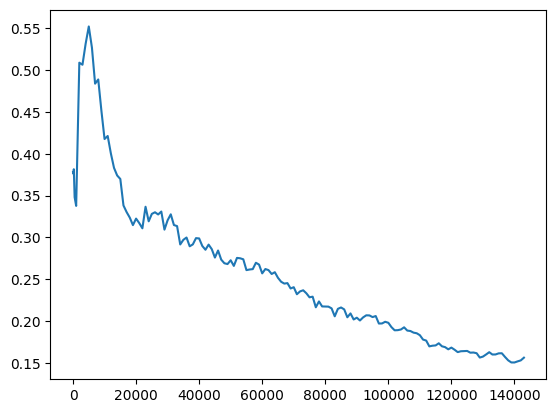

In [3]:
plt.plot(t,df['W_t'][0])

In [ ]:
n_heads = df['head'].max() + 1
n_layers = df['layer'].max() + 1
n_model_squared = len(df) /n_heads / n_layers
n_model = int(np.sqrt(n_model_squared))

/var/folders/_5/w5f7n1zx5t521cn85gjbd2400000gn/T/ipykernel_32845/242190335.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


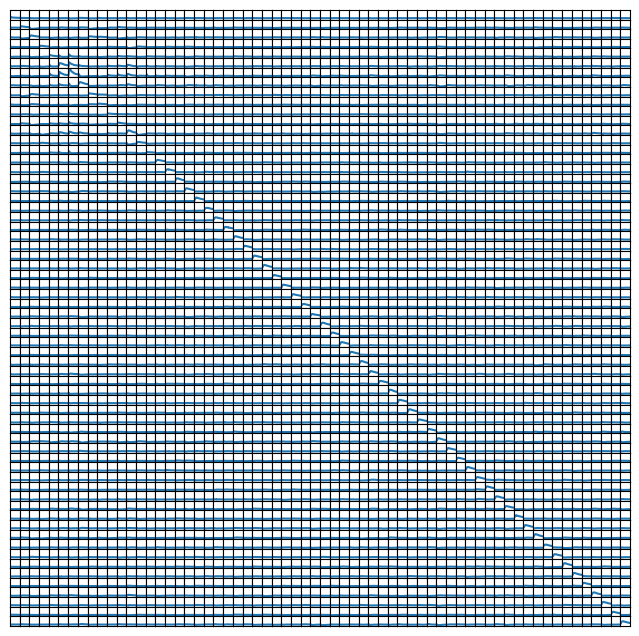

In [ ]:
layer_idx = 0
head_idx = 0
df_lh = df.query(f"layer == {layer_idx} and head == {head_idx}")
W_vs_t = df_lh['W_t']
nrows = int(np.sqrt(len(W_vs_t)))
ncolumns = nrows
ymin = np.min(np.concatenate(W_vs_t.values))
ymax = np.max(np.concatenate(W_vs_t.values))
fig, axes = plt.subplots(nrows,ncolumns, figsize=(8, 8))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.plot(t,W_vs_t[i])
    ax.set_ylim(ymin,ymax)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0)
